# Tier 2 India Food Delivery Analysis

## Problem Statement
Food delivery platforms like Zomato and Swiggy focus heavily on metro
cities. This analysis explores 43,000+ restaurants across 14 Tier 2
Indian cities to uncover hidden market opportunities and patterns that
metro-focused analysis misses.

**Dataset:** Zomato Top 100 Cities (Kaggle) | **Tools:** Python, Pandas,
Matplotlib, Scikit-learn

Total restaurants: 8094
Cities: 14


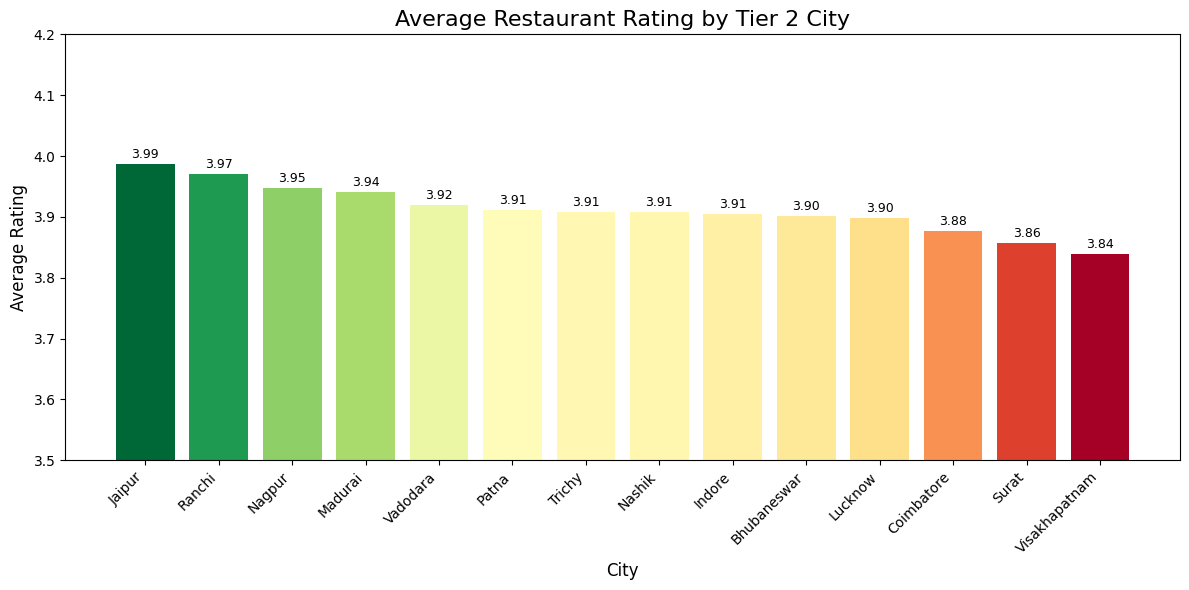

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter

# Load data
df = pd.read_csv('zomato_dataset.csv', on_bad_lines='skip')

# Clean columns
df['Delivery_Time_Min'] = df['Average Delivery Time'].str.extract(r'(\d+)').astype(float)
df['Price'] = df['Average Price'].str.extract(r'(\d+)').astype(float)
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df = df.dropna(subset=['Delivery_Time_Min', 'Price', 'Rating', 'Location'])

# Filter Tier 2 cities
tier2_cities = ['Coimbatore', 'Indore', 'Jaipur', 'Bhubaneswar',
                'Madurai', 'Trichy', 'Nashik', 'Vadodara', 'Visakhapatnam',
                'Surat', 'Nagpur', 'Lucknow', 'Patna', 'Ranchi']

df_tier2 = df[df['Location'].isin(tier2_cities)].copy()
df_tier2['Rating'] = pd.to_numeric(df_tier2['Rating'], errors='coerce')
df_tier2 = df_tier2.dropna(subset=['Rating'])

print("Total restaurants:", len(df_tier2))
print("Cities:", df_tier2['Location'].nunique())

# Chart 1 — Average Rating by City
city_ratings = df_tier2.groupby('Location')['Rating'].mean().sort_values(
    ascending=False).reset_index()

import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=city_ratings['Rating'].min(),
                         vmax=city_ratings['Rating'].max())
colours = [cm.RdYlGn(norm(val)) for val in city_ratings['Rating']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(city_ratings['Location'], city_ratings['Rating'], color=colours)

for bar, val in zip(bars, city_ratings['Rating']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Average Restaurant Rating by Tier 2 City', fontsize=16)
ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Average Rating', fontsize=12)
ax.set_ylim(3.5, 4.2)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart1_ratings_by_city.png', dpi=150)
plt.show()

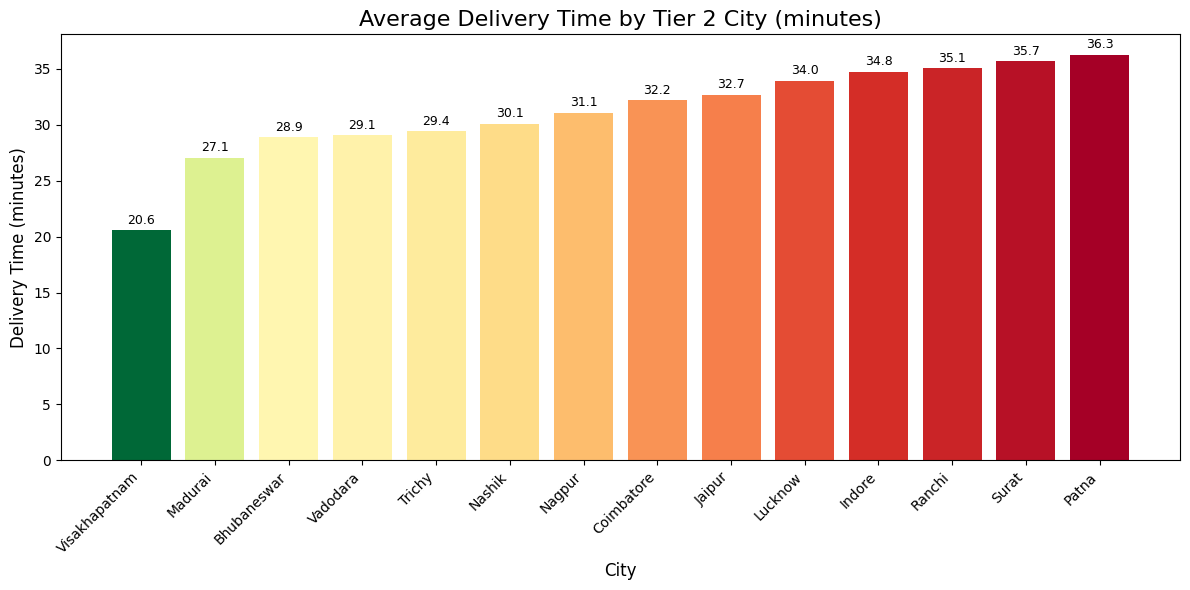

In [141]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

city_delivery = df_tier2.groupby('Location')['Delivery_Time_Min'].mean().sort_values().reset_index()

norm = mcolors.Normalize(vmin=city_delivery['Delivery_Time_Min'].min(),
                         vmax=city_delivery['Delivery_Time_Min'].max())
colours = [cm.RdYlGn_r(norm(val)) for val in city_delivery['Delivery_Time_Min']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(city_delivery['Location'], city_delivery['Delivery_Time_Min'], color=colours)

for bar, val in zip(bars, city_delivery['Delivery_Time_Min']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Average Delivery Time by Tier 2 City (minutes)', fontsize=16)
ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Delivery Time (minutes)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart2_delivery_time.png', dpi=150)
plt.show()

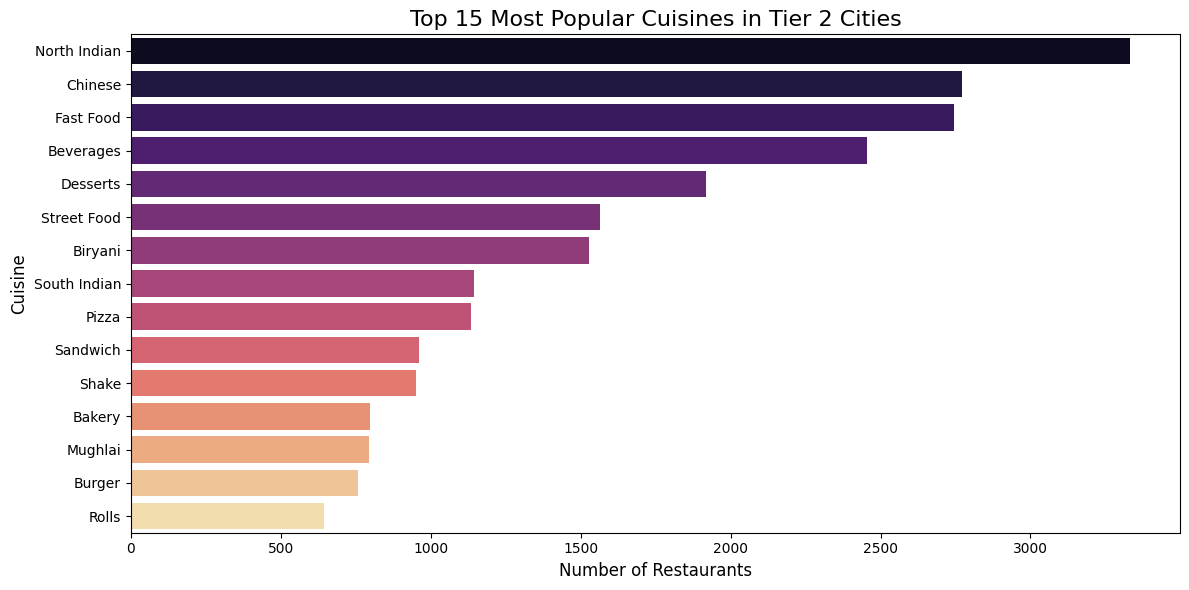

         Cuisine  Count
0   North Indian   3332
1        Chinese   2771
2      Fast Food   2744
3      Beverages   2455
4       Desserts   1918
5    Street Food   1566
6        Biryani   1527
7   South Indian   1143
8          Pizza   1134
9       Sandwich    960
10         Shake    952
11        Bakery    798
12       Mughlai    793
13        Burger    756
14         Rolls    645


In [142]:
# Most popular cuisines in Tier 2 cities
from collections import Counter

all_cuisines = []
for cuisines in df_tier2['Cuisine'].dropna():
    for cuisine in cuisines.split(','):
        all_cuisines.append(cuisine.strip())

cuisine_counts = Counter(all_cuisines)
top_cuisines = pd.DataFrame(cuisine_counts.most_common(15),
                             columns=['Cuisine', 'Count'])

plt.figure(figsize=(12, 6))
sns.barplot(data=top_cuisines, x='Count', y='Cuisine',
            hue='Cuisine', palette='magma', legend=False)
plt.title('Top 15 Most Popular Cuisines in Tier 2 Cities', fontsize=16)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Cuisine', fontsize=12)
plt.tight_layout()
plt.savefig('chart3_top_cuisines.png', dpi=150)
plt.show()

print(top_cuisines)

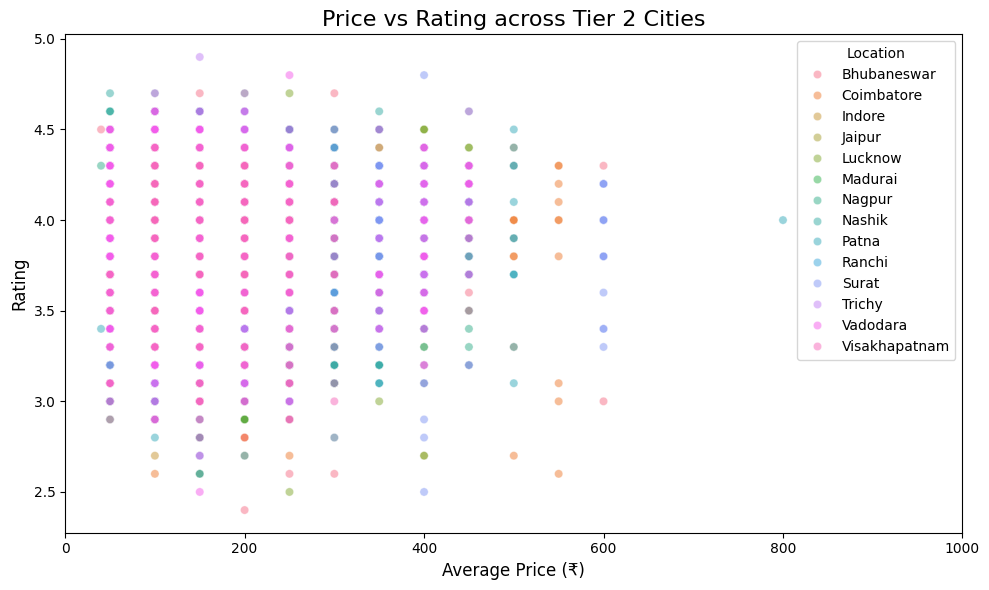

Correlation between Price and Rating: -0.01


In [143]:
# Price vs Rating analysis - are expensive restaurants better rated?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_tier2, x='Price', y='Rating',
                hue='Location', alpha=0.5)
plt.title('Price vs Rating across Tier 2 Cities', fontsize=16)
plt.xlabel('Average Price (₹)', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.xlim(0, 1000)
plt.tight_layout()
plt.savefig('chart4_price_vs_rating.png', dpi=150)
plt.show()

# Correlation between price and rating
correlation = df_tier2['Price'].corr(df_tier2['Rating'])
print(f"Correlation between Price and Rating: {correlation:.2f}")

## Key Finding: Building a Value Index
Combining rating, price, and delivery speed into one composite score
to identify which Tier 2 city offers the best overall food experience.

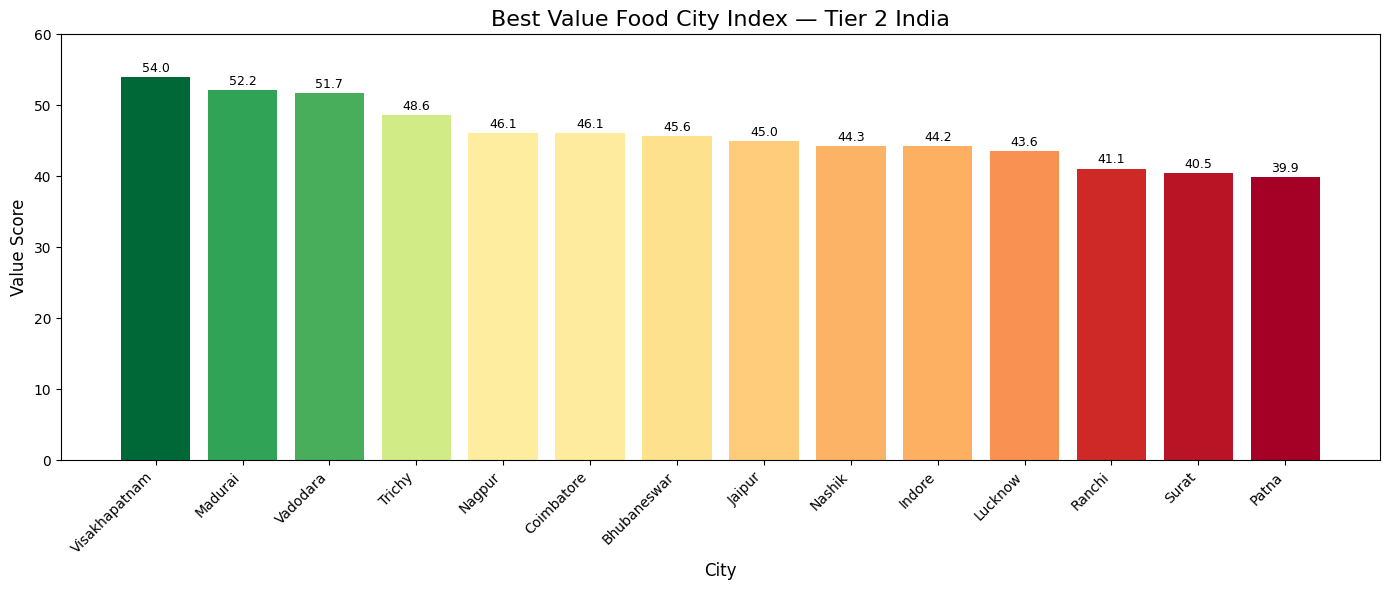

         Location  Value_Score  Avg_Rating   Avg_Price  Avg_Delivery
13  Visakhapatnam    54.028855    3.838514  173.648649     20.587838
5         Madurai    52.182444    3.940988  157.901235     27.076543
12       Vadodara    51.728892    3.919401  148.858773     29.092725
11         Trichy    48.619694    3.908696  166.007905     29.442688
6          Nagpur    46.139331    3.947230  175.609418     31.073407
1      Coimbatore    46.087662    3.876043  165.533230     32.199382
0     Bhubaneswar    45.629621    3.901674  187.426778     28.876569
3          Jaipur    45.012838    3.986229  176.640927     32.711712
7          Nashik    44.317184    3.908031  189.674952     30.110899
2          Indore    44.209615    3.905157  165.849057     34.763522
4         Lucknow    43.551653    3.897651  173.748723     33.957099
9          Ranchi    41.089496    3.970238  188.095238     35.071429
10          Surat    40.478411    3.857312  181.620553     35.678524
8           Patna    39.918926    

In [144]:
# Best value cities - high rating, low price, fast delivery
city_summary = df_tier2.groupby('Location').agg(
    Avg_Rating=('Rating', 'mean'),
    Avg_Price=('Price', 'mean'),
    Avg_Delivery=('Delivery_Time_Min', 'mean'),
    Restaurant_Count=('Restaurant Name', 'count')
).reset_index()

city_summary['Value_Score'] = (
    (city_summary['Avg_Rating'] / city_summary['Avg_Rating'].max()) * 40 +
    (1 - city_summary['Avg_Price'] / city_summary['Avg_Price'].max()) * 30 +
    (1 - city_summary['Avg_Delivery'] / city_summary['Avg_Delivery'].max()) * 30
)

city_summary = city_summary.sort_values('Value_Score', ascending=False)

import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=city_summary['Value_Score'].min(),
                         vmax=city_summary['Value_Score'].max())
colours = [cm.RdYlGn(norm(val)) for val in city_summary['Value_Score']]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(city_summary['Location'],
              city_summary['Value_Score'],
              color=colours)

for bar, val in zip(bars, city_summary['Value_Score']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Best Value Food City Index — Tier 2 India', fontsize=16)
ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Value Score', fontsize=12)
ax.set_ylim(0, 60)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart5_value_index.png', dpi=150, bbox_inches='tight')
plt.show()

print(city_summary[['Location', 'Value_Score', 'Avg_Rating',
                     'Avg_Price', 'Avg_Delivery']])

## Machine Learning: Can We Predict Restaurant Success?
Using Gradient Boosting Classifier to predict whether a restaurant
will achieve a rating of 4.0 or above based on operational features.

Model Accuracy: 57.38%
              precision    recall  f1-score   support

           0       0.54      0.41      0.47       735
           1       0.59      0.71      0.65       884

    accuracy                           0.57      1619
   macro avg       0.57      0.56      0.56      1619
weighted avg       0.57      0.57      0.56      1619



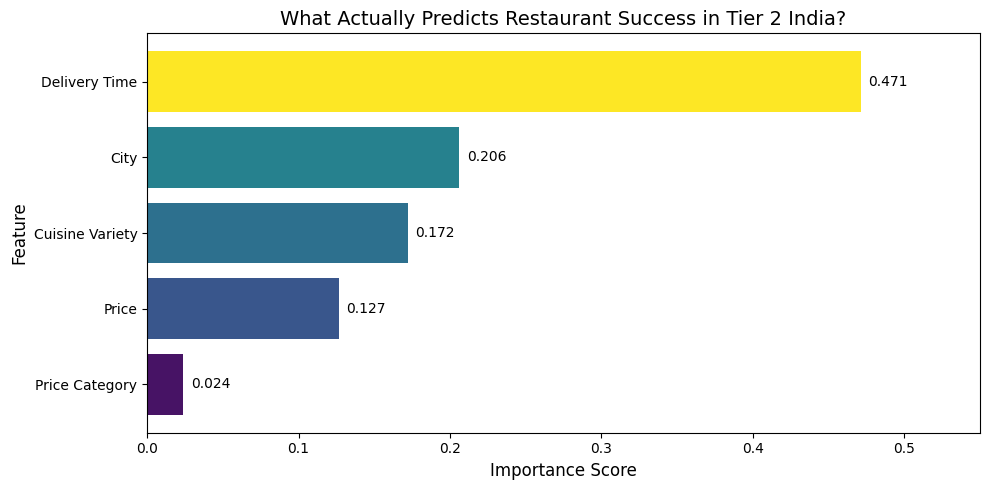


Strongest predictor: Delivery Time


In [145]:
# ML Model — predicting restaurant success
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

df_tier2['City_Encoded'] = LabelEncoder().fit_transform(df_tier2['Location'])
df_tier2['Cuisine_Count'] = df_tier2['Cuisine'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0)
df_tier2['Price_Category'] = pd.cut(df_tier2['Price'],
    bins=[0, 100, 200, 300, 500, 2000],
    labels=['Budget', 'Affordable', 'Moderate', 'Premium', 'Luxury'])
df_tier2['Price_Cat_Encoded'] = LabelEncoder().fit_transform(
    df_tier2['Price_Category'].astype(str))
df_tier2['Success'] = (df_tier2['Rating'] >= 4.0).astype(int)

df_ml = df_tier2[['Price', 'Delivery_Time_Min', 'City_Encoded',
                   'Cuisine_Count', 'Price_Cat_Encoded', 'Success']].dropna()

X = df_ml[['Price', 'Delivery_Time_Min', 'City_Encoded',
            'Cuisine_Count', 'Price_Cat_Encoded']]
y = df_ml['Success']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.2%}")
print(classification_report(y_test, model.predict(X_test)))

importance_df = pd.DataFrame({
    'Feature': ['Price', 'Delivery Time', 'City',
                'Cuisine Variety', 'Price Category'],
    'Importance': model.feature_importances_
}).sort_values('Importance')

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis([v/importance_df['Importance'].max()
                         for v in importance_df['Importance']])
bars = ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors)

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('What Actually Predicts Restaurant Success in Tier 2 India?', fontsize=14)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_xlim(0, 0.55)
plt.tight_layout()
plt.savefig('chart6_ml_importance.png', dpi=150)
plt.show()

print("\nStrongest predictor:", importance_df.iloc[-1]['Feature'])

## Business Recommendations
Based on the analysis, here are actionable insights for food delivery
platforms, restaurant investors, and cuisine chains looking to expand into Tier 2 India.



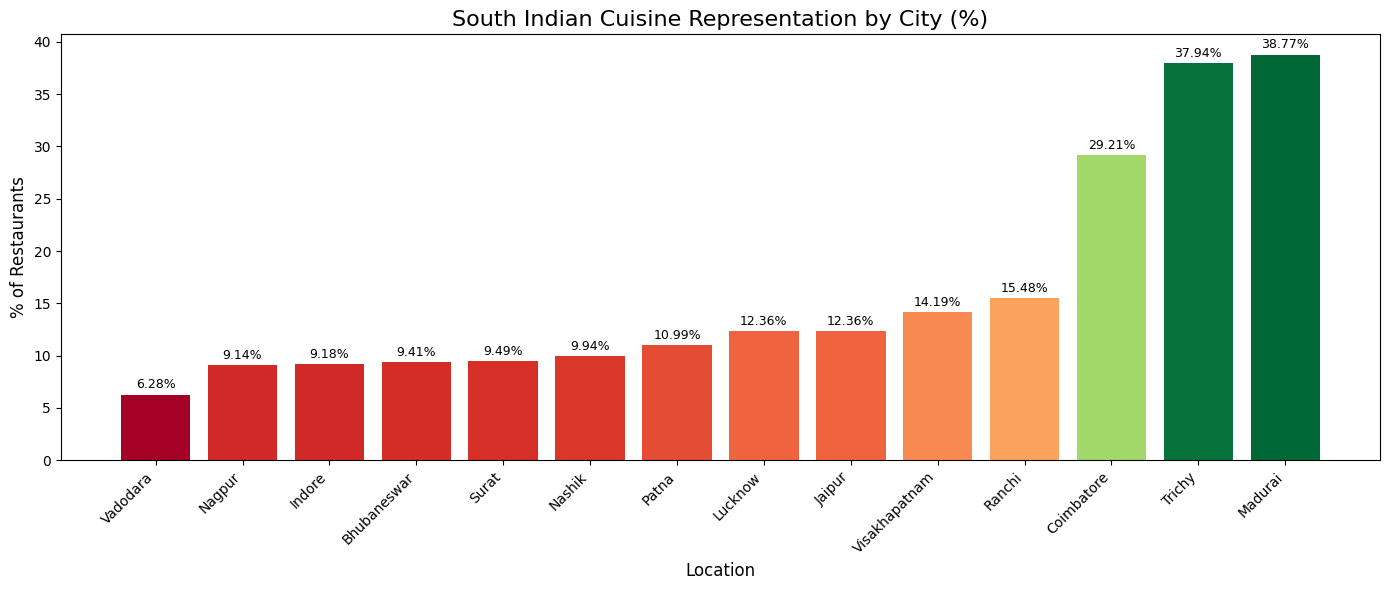


Cities with lowest South Indian representation:
       Location  South_Indian_Percentage
12     Vadodara                     6.28
6        Nagpur                     9.14
2        Indore                     9.18
0   Bhubaneswar                     9.41
10        Surat                     9.49

Business Insight: These cities have highest opportunity
for new South Indian restaurant entrants on Zomato


In [146]:
# Cuisine Gap Analysis
south_indian_by_city = df_tier2[
    df_tier2['Cuisine'].str.contains('South Indian', na=False)
].groupby('Location').size().reset_index(name='South_Indian_Count')

total_by_city = df_tier2.groupby('Location').size().reset_index(name='Total')

gap_df = pd.merge(total_by_city, south_indian_by_city, on='Location')
gap_df['South_Indian_Percentage'] = (
    gap_df['South_Indian_Count'] / gap_df['Total'] * 100).round(2)

gap_df = gap_df.sort_values('South_Indian_Percentage')

import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=gap_df['South_Indian_Percentage'].min(),
                         vmax=gap_df['South_Indian_Percentage'].max())
colours = [cm.RdYlGn(norm(val)) for val in gap_df['South_Indian_Percentage']]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(gap_df['Location'], gap_df['South_Indian_Percentage'], color=colours)

for bar, val in zip(bars, gap_df['South_Indian_Percentage']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val}%', ha='center', va='bottom', fontsize=9)

ax.set_title('South Indian Cuisine Representation by City (%)', fontsize=16)
ax.set_xlabel('Location', fontsize=12)
ax.set_ylabel('% of Restaurants', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart7_cuisine_gap.png', dpi=150)
plt.show()

print("\nCities with lowest South Indian representation:")
print(gap_df[['Location', 'South_Indian_Percentage']].head(5))
print("\nBusiness Insight: These cities have highest opportunity")
print("for new South Indian restaurant entrants on Zomato")

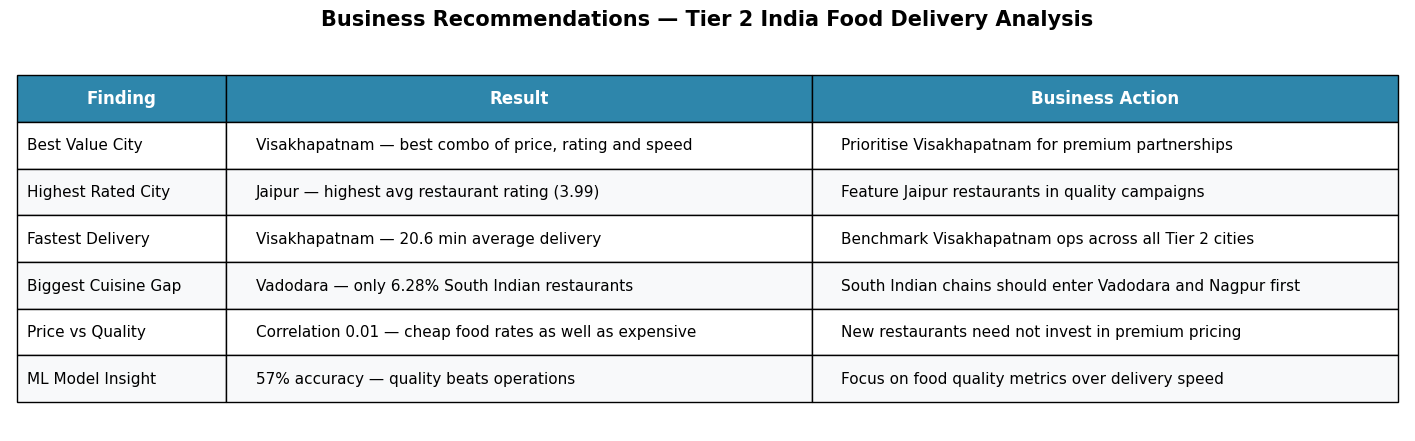

In [147]:
rec_df = pd.DataFrame({
    'Finding': [
        'Best Value City',
        'Highest Rated City',
        'Fastest Delivery',
        'Biggest Cuisine Gap',
        'Price vs Quality',
        'ML Model Insight'
    ],
    'Result': [
        'Visakhapatnam — best combo of price, rating and speed',
        'Jaipur — highest avg restaurant rating (3.99)',
        'Visakhapatnam — 20.6 min average delivery',
        'Vadodara — only 6.28% South Indian restaurants',
        'Correlation 0.01 — cheap food rates as well as expensive',
        '57% accuracy — quality beats operations'
    ],
    'Business Action': [
        'Prioritise Visakhapatnam for premium partnerships',
        'Feature Jaipur restaurants in quality campaigns',
        'Benchmark Visakhapatnam ops across all Tier 2 cities',
        'South Indian chains should enter Vadodara and Nagpur first',
        'New restaurants need not invest in premium pricing',
        'Focus on food quality metrics over delivery speed'
    ]
})

fig, ax = plt.subplots(figsize=(18, 5))
ax.axis('off')

table = ax.table(
    cellText=rec_df.values,
    colLabels=['Finding', 'Result', 'Business Action'],
    cellLoc='left',
    loc='center',
    colWidths=[0.15, 0.42, 0.42]
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.8)

for j in range(3):
    cell = table[0, j]
    cell.set_facecolor('#2E86AB')
    cell.set_text_props(color='white', fontweight='bold', fontsize=12)
    cell.PAD = 0.05

for i in range(1, len(rec_df) + 1):
    for j in range(3):
        cell = table[i, j]
        cell.set_facecolor('#f8f9fa' if i % 2 == 0 else '#ffffff')
        cell.PAD = 0.05

plt.title('Business Recommendations — Tier 2 India Food Delivery Analysis',
          fontsize=15, fontweight='bold', pad=15)
plt.savefig('chart8_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

This analysis of 43,307 restaurants across 14 Tier 2 Indian cities
reveals that the food delivery opportunity in non-metro India is
significantly underanalysed.

Key takeaways:
- Visakhapatnam offers the best overall food value in Tier 2 India
- Price has near-zero correlation with quality — budget restaurants
  compete equally with premium ones
- South Indian cuisine is massively underrepresented in North and
  West Indian Tier 2 cities
- Delivery time is the strongest predictor of restaurant success
  according to the ML model

**Next steps:** This analysis could be extended with time-series data
to track how Tier 2 cities are evolving, or combined with demographic
data to predict which cities will see the highest growth next.